# EDA of the HCI-tagging Emotion Dataset

Quick exploratory analysis for the **emotion-elicitation** subset of HCI-tagging, aligned with the eSEEd EDA workflow.

In [16]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)

## Setup Paths

In [17]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'src').exists():
            return candidate
    raise RuntimeError('Could not infer project root from current working directory.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data/processed/hci-tagging/emotion-elicitation'
CACHE_PATH = PROJECT_ROOT / 'data/processed/cached_hci_tagging_emotion.csv'

EDA_ROOT = PROJECT_ROOT / 'src/data/EDA'
PLOTS_DIR = EDA_ROOT / 'plots/hci-tagging-emotion'
TABLES_DIR = EDA_ROOT / 'tables/hci-tagging-emotion'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR)
print('PLOTS_DIR:', PLOTS_DIR)
print('TABLES_DIR:', TABLES_DIR)

PROJECT_ROOT: /home/ppg/eyetracking/GFM-for-eyetracker
DATA_DIR: /home/ppg/eyetracking/GFM-for-eyetracker/data/processed/hci-tagging/emotion-elicitation
PLOTS_DIR: /home/ppg/eyetracking/GFM-for-eyetracker/src/data/EDA/plots/hci-tagging-emotion
TABLES_DIR: /home/ppg/eyetracking/GFM-for-eyetracker/src/data/EDA/tables/hci-tagging-emotion


## Prepare Dataset - Load - Cache

In [18]:
def load_hci_emotion_dataset(
    data_dir: Path,
    cache_path: Path,
    use_cache: bool = True,
    force_reload: bool = False,
) -> pd.DataFrame:
    """Load all emotion-elicitation CSV files and optionally cache merged dataframe."""
    if use_cache and cache_path.exists() and not force_reload:
        print(f'Loading cached dataframe from {cache_path}')
        df_cached = pd.read_csv(cache_path)
        return df_cached

    files = sorted(data_dir.glob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV files found in {data_dir}')

    parts = []
    for file_path in files:
        part = pd.read_csv(file_path)
        part['file-name'] = file_path.name
        parts.append(part)

    df_merged = pd.concat(parts, ignore_index=True)

    numeric_candidates = [
        'time-rel-seconds', 'x-avg', 'y-avg',
        'confidence-gaze-left', 'confidence-gaze-right',
        'pupil-size-left-avg', 'pupil-size-right-avg',
        'raw-validity-gaze-left', 'raw-validity-gaze-right',
        'emotion-id', 'emotion-arousal', 'emotion-valence',
        'emotion-control', 'emotion-predictability',
    ]
    for col in numeric_candidates:
        if col in df_merged.columns:
            df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

    if use_cache:
        df_merged.to_csv(cache_path, index=False)
        print(f'Cached merged dataframe to {cache_path}')
        df_merged_subset = df_merged.head(100000)
        df_merged_subset.to_csv(cache_path.with_name(cache_path.stem + '_subset_100K.csv'), index=False)
        print(f'Cached subset of merged dataframe to {cache_path.with_name(cache_path.stem + "_subset_100K.csv")}')

    return df_merged

In [19]:
df = load_hci_emotion_dataset(DATA_DIR, CACHE_PATH, use_cache=True, force_reload=True)
dfOG = df.copy()

print('Rows:', len(df))
print('Columns:', len(df.columns))
display(df.sample(3))

Cached merged dataframe to /home/ppg/eyetracking/GFM-for-eyetracker/data/processed/cached_hci_tagging_emotion.csv
Cached subset of merged dataframe to /home/ppg/eyetracking/GFM-for-eyetracker/data/processed/cached_hci_tagging_emotion_subset_100K.csv
Rows: 3797165
Columns: 23


,time-rel-seconds,x-avg,y-avg,confidence-gaze-left,confidence-gaze-right,pupil-size-left-avg,pupil-size-right-avg,subject,recording,section,session-id,experiment-type,is-stimulus,raw-validity-gaze-left,raw-validity-gaze-right,emotion-id,emotion-arousal,emotion-valence,emotion-control,emotion-predictability,emotion-source,emotion-derivation-status,file-name
832655,87.410327,558.0,429.0,1.0,1.0,3.423577,3.586866,P16,52.avi,16,1966,Rec1,True,0.0,0.0,0.0,3.0,5.0,5.0,7.0,xml,ok,P16-Rec1-All-Data-New_Section_16.csv
742905,76.267972,616.0,272.0,1.0,1.0,3.131506,3.266074,P14,138.avi,32,1722,Rec1,True,0.0,0.0,0.0,1.0,4.0,6.0,9.0,xml,ok,P14-Rec1-All-Data-New_Section_32.csv
2528038,11.242730,627.0,427.0,1.0,1.0,2.849432,2.762344,P27,earworm_f.avi,6,3386,Rec1,True,0.0,0.0,0.0,2.0,5.0,8.0,8.0,xml,ok,P27-Rec1-All-Data-New_Section_6.csv


## Cohorts and Coverage

In [20]:
required_label_cols = [
    'emotion-id', 'emotion-arousal', 'emotion-valence',
    'emotion-control', 'emotion-predictability'
]

is_label_complete = pd.Series(True, index=df.index)
for c in required_label_cols:
    is_label_complete &= df[c].notna()

is_status_ok = df['emotion-derivation-status'].eq('ok') if 'emotion-derivation-status' in df.columns else pd.Series(False, index=df.index)

df_labeled = df[is_status_ok & is_label_complete].copy()
df_unlabeled = df[~(is_status_ok & is_label_complete)].copy()

summary_rows = [
    ('all', len(df), df['subject'].nunique(), df[['subject','recording','section']].drop_duplicates().shape[0]),
    ('labeled', len(df_labeled), df_labeled['subject'].nunique(), df_labeled[['subject','recording','section']].drop_duplicates().shape[0]),
    ('unlabeled', len(df_unlabeled), df_unlabeled['subject'].nunique(), df_unlabeled[['subject','recording','section']].drop_duplicates().shape[0]),
]
df_cohort_summary = pd.DataFrame(summary_rows, columns=['cohort','rows','n_subjects','n_subject_recording_sections'])
display(df_cohort_summary)

status_counts = df['emotion-derivation-status'].fillna('<missing>').value_counts().rename_axis('emotion-derivation-status').reset_index(name='count')
source_counts = df['emotion-source'].fillna('<missing>').value_counts().rename_axis('emotion-source').reset_index(name='count')

display(status_counts)
display(source_counts)

df_cohort_summary.to_csv(TABLES_DIR / 'cohort_summary.csv', index=False)
status_counts.to_csv(TABLES_DIR / 'emotion_derivation_status_counts.csv', index=False)
source_counts.to_csv(TABLES_DIR / 'emotion_source_counts.csv', index=False)

,cohort,rows,n_subjects,n_subject_recording_sections
0,all,3797165,24,942
1,labeled,3214000,24,470
2,unlabeled,583165,24,472


,emotion-derivation-status,count
0,ok,3214000
1,not-reported,583165


,emotion-source,count
0,xml,3085470
1,none,583165
2,guide-cut,128530


## Percentage of NaNs

,column,nan_pct
0,emotion-valence,15.357905
1,emotion-arousal,15.357905
2,emotion-predictability,15.357905
3,emotion-control,15.357905
4,emotion-id,15.357905
5,y-avg,5.567575
6,x-avg,5.567575
7,confidence-gaze-left,5.567575
8,confidence-gaze-right,5.567575
9,pupil-size-left-avg,5.562624


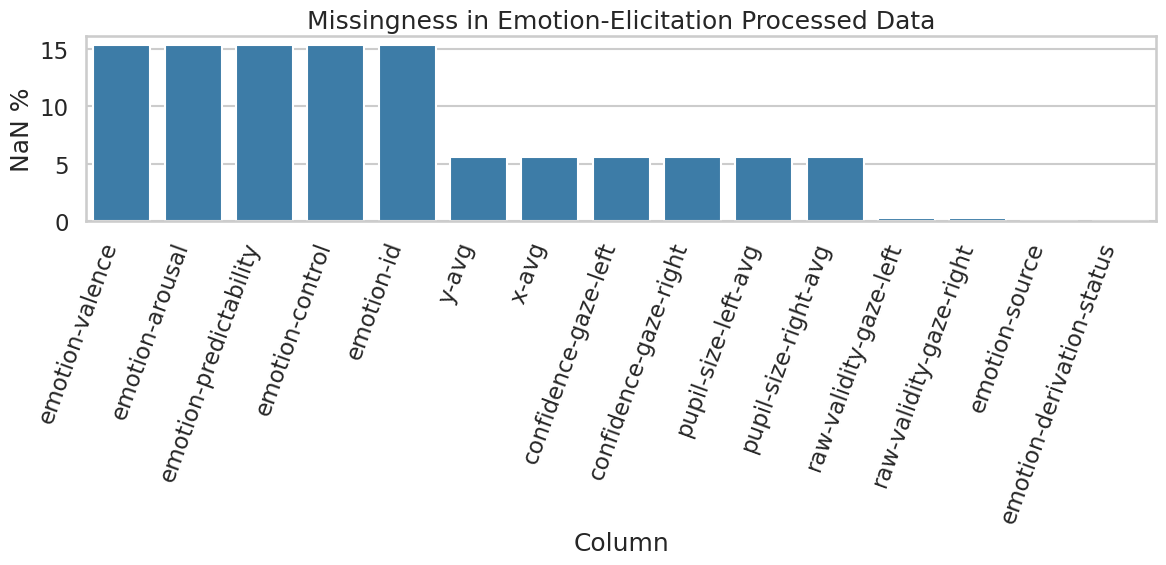

In [21]:
analysis_cols = [
    'x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg',
    'confidence-gaze-left', 'confidence-gaze-right',
    'raw-validity-gaze-left', 'raw-validity-gaze-right',
    'emotion-id', 'emotion-arousal', 'emotion-valence', 'emotion-control', 'emotion-predictability',
    'emotion-source', 'emotion-derivation-status',
]
analysis_cols = [c for c in analysis_cols if c in df.columns]

nan_pct = (df[analysis_cols].isna().mean() * 100).sort_values(ascending=False).rename('nan_pct').reset_index().rename(columns={'index':'column'})
display(nan_pct)

plt.figure(figsize=(12, 6))
sns.barplot(data=nan_pct, x='column', y='nan_pct', color='#2C7FB8')
plt.xticks(rotation=70, ha='right')
plt.ylabel('NaN %')
plt.xlabel('Column')
plt.title('Missingness in Emotion-Elicitation Processed Data')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'nan_percentage_by_column.png', dpi=180)
plt.show()

nan_pct.to_csv(TABLES_DIR / 'nan_percentage_by_column.csv', index=False)

## Emotion Distributions

,emotion-id,count,emotion-name
0,0,726659,Neutral
1,1,78768,Anger
2,2,313779,Disgust
3,3,177615,Fear
4,4,449187,Joy/Happiness
5,5,473295,Sadness
6,6,156821,Surprise
7,11,669438,Amusement
8,12,168438,Anxiety


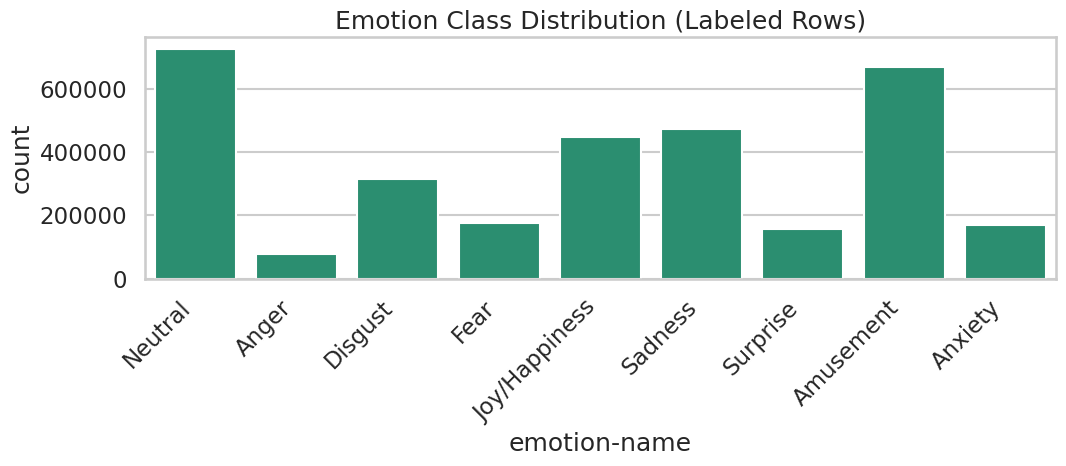

In [22]:
emotion_id_to_name = {
    0: 'Neutral', 1: 'Anger', 2: 'Disgust', 3: 'Fear', 4: 'Joy/Happiness',
    5: 'Sadness', 6: 'Surprise', 7: 'Scream', 8: 'Bored', 9: 'Sleepy',
    10: 'Unknown', 11: 'Amusement', 12: 'Anxiety',
}

emotion_counts = (
    df_labeled['emotion-id']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('emotion-id')
    .reset_index(name='count')
)
emotion_counts['emotion-name'] = emotion_counts['emotion-id'].map(emotion_id_to_name).fillna('Unknown-ID')
display(emotion_counts)

plt.figure(figsize=(11, 5))
sns.barplot(data=emotion_counts, x='emotion-name', y='count', color='#1B9E77')
plt.xticks(rotation=45, ha='right')
plt.title('Emotion Class Distribution (Labeled Rows)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'emotion_class_distribution.png', dpi=180)
plt.show()

emotion_counts.to_csv(TABLES_DIR / 'emotion_class_distribution.csv', index=False)

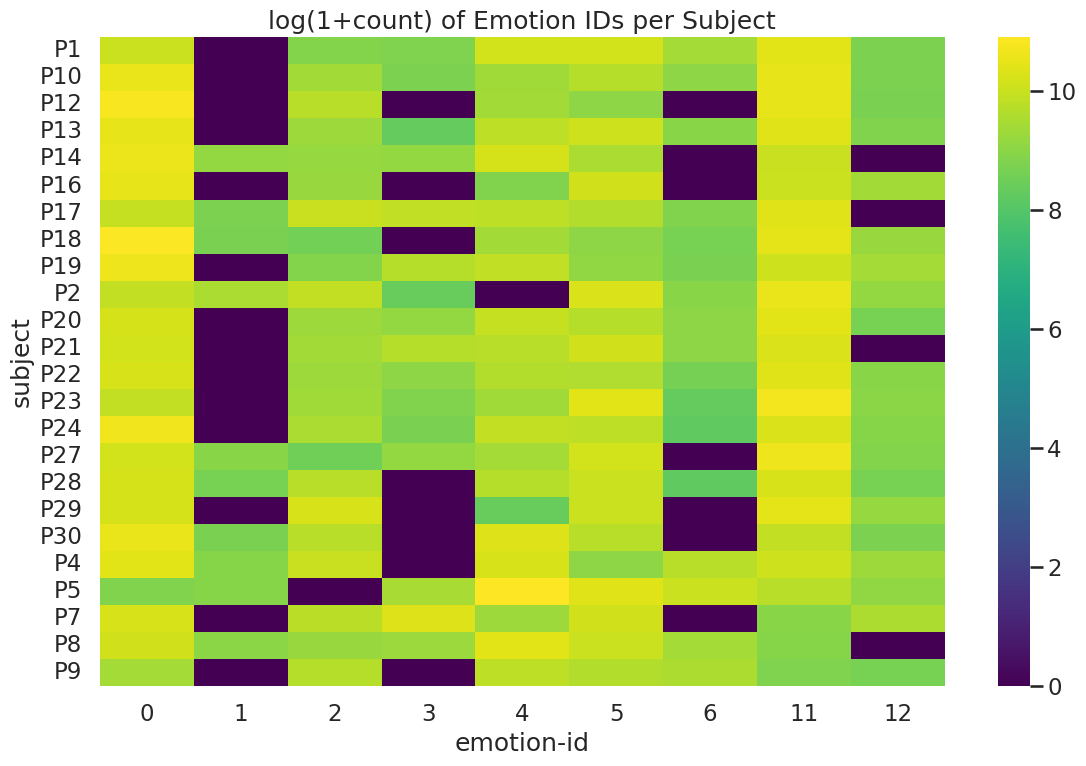

In [23]:
emotion_by_subject = (
    df_labeled.dropna(subset=['emotion-id'])
    .assign(emotion_id=lambda x: x['emotion-id'].astype(int))
    .groupby(['subject', 'emotion_id'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(np.log1p(emotion_by_subject), cmap='viridis')
plt.title('log(1+count) of Emotion IDs per Subject')
plt.xlabel('emotion-id')
plt.ylabel('subject')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'emotion_by_subject_heatmap.png', dpi=180)
plt.show()

emotion_by_subject.to_csv(TABLES_DIR / 'emotion_by_subject_counts.csv')

## Signal Distributions by Emotion

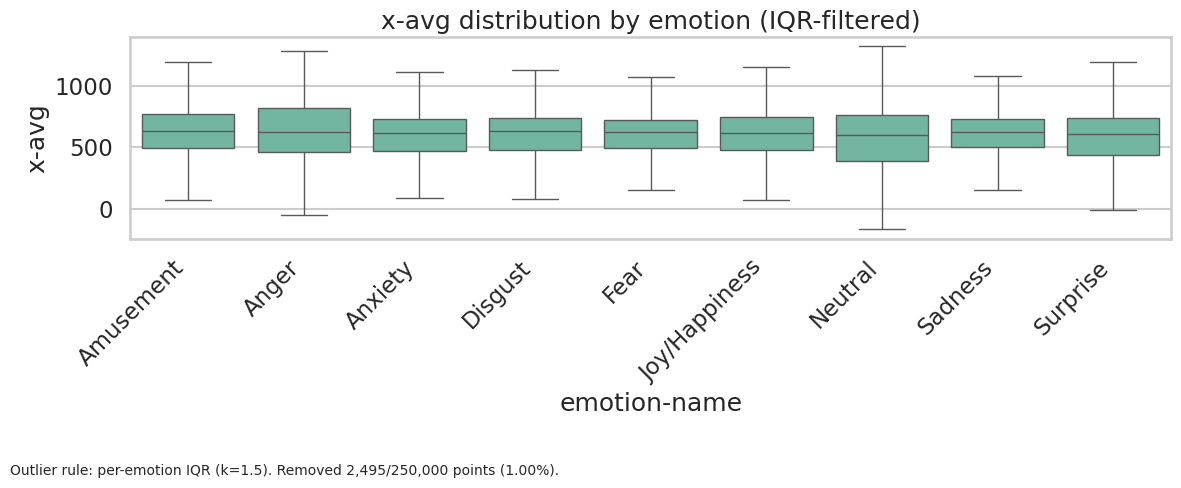

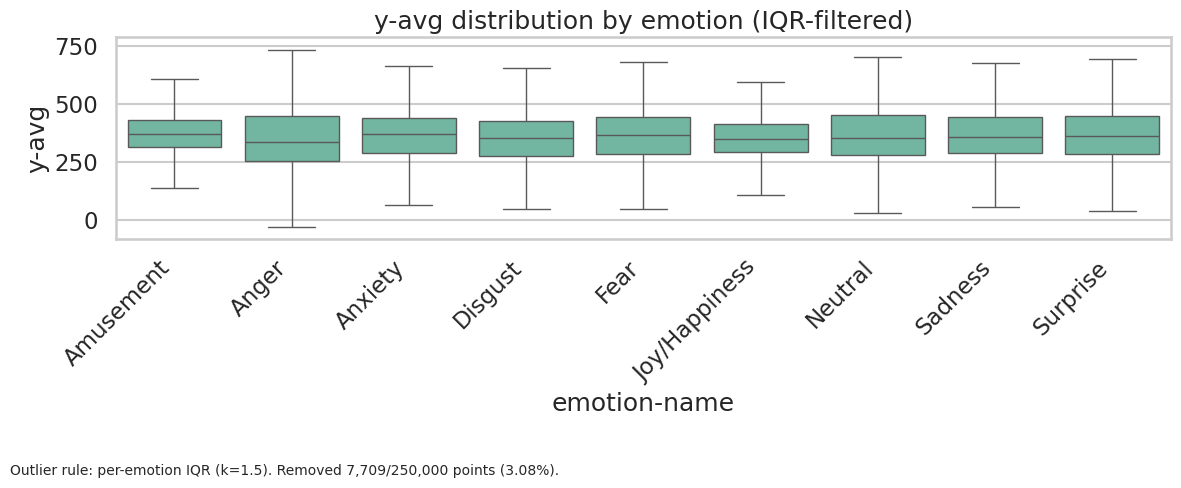

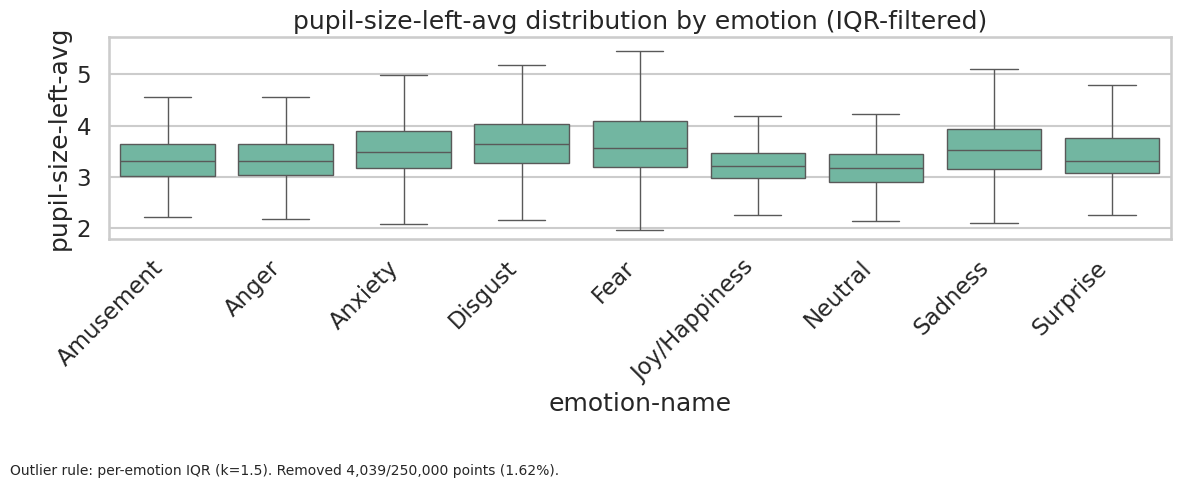

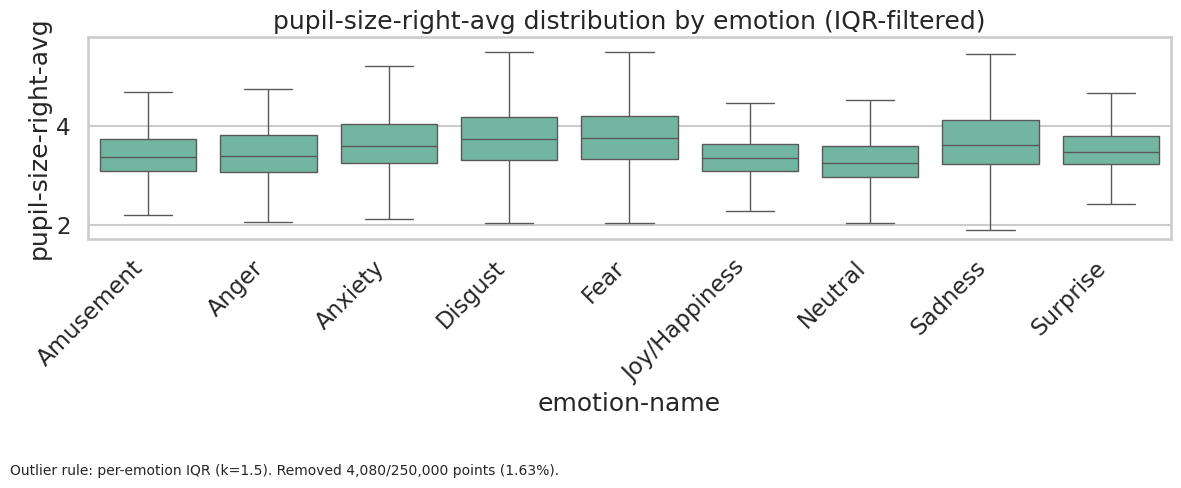

In [24]:
signal_cols = ['x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']
signal_cols = [c for c in signal_cols if c in df_labeled.columns]

plot_df = df_labeled.dropna(subset=['emotion-id'] + signal_cols).copy()
if len(plot_df) > 250_000:
    plot_df = plot_df.sample(n=250_000, random_state=42)

plot_df['emotion-id'] = plot_df['emotion-id'].astype(int)
plot_df['emotion-name'] = plot_df['emotion-id'].map(emotion_id_to_name).fillna('Unknown-ID')


def remove_outliers_iqr_by_group(df_in: pd.DataFrame, value_col: str, group_col: str, iqr_k: float = 1.5) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Remove outliers per group using IQR bounds and return filtered df + per-group stats.
    parts = []
    stats_rows = []

    for group_name, g in df_in.groupby(group_col, dropna=False):
        s = g[value_col]
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr) or iqr == 0:
            lower = s.min()
            upper = s.max()
        else:
            lower = q1 - iqr_k * iqr
            upper = q3 + iqr_k * iqr

        keep_mask = s.between(lower, upper, inclusive='both')
        kept = g[keep_mask]
        removed_n = int((~keep_mask).sum())

        parts.append(kept)
        stats_rows.append({
            'emotion-name': group_name,
            'column': value_col,
            'n_total': int(len(g)),
            'n_kept': int(len(kept)),
            'n_removed': removed_n,
            'pct_removed': (removed_n / len(g) * 100.0) if len(g) else 0.0,
            'lower_bound': float(lower) if pd.notna(lower) else np.nan,
            'upper_bound': float(upper) if pd.notna(upper) else np.nan,
        })

    filtered = pd.concat(parts, ignore_index=True) if parts else df_in.iloc[0:0].copy()
    stats_df = pd.DataFrame(stats_rows)
    return filtered, stats_df


for col in signal_cols:
    filtered_df, outlier_stats = remove_outliers_iqr_by_group(plot_df, value_col=col, group_col='emotion-name', iqr_k=1.5)

    total_points = int(outlier_stats['n_total'].sum())
    removed_points = int(outlier_stats['n_removed'].sum())
    removed_pct = (removed_points / total_points * 100.0) if total_points else 0.0

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=filtered_df, x='emotion-name', y=col, color='#66C2A5', fliersize=0)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} distribution by emotion (IQR-filtered)')
    plt.xlabel('emotion-name')
    plt.ylabel(col)

    note = f'Outlier rule: per-emotion IQR (k=1.5). Removed {removed_points:,}/{total_points:,} points ({removed_pct:.2f}%).'
    if removed_pct >= 5.0:
        note += ' NOTE: substantial outlier removal; interpret class proportions with care.'
    plt.figtext(0.01, 0.01, note, ha='left', va='bottom', fontsize=10)

    plt.tight_layout(rect=(0, 0.08, 1, 1))
    plt.savefig(PLOTS_DIR / f'{col}_by_emotion_boxplot_iqr_filtered.png', dpi=180)
    plt.show()

    summary = (
        filtered_df.groupby('emotion-name')[col]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary.to_csv(TABLES_DIR / f'{col}_by_emotion_summary_iqr_filtered.csv', index=False)
    outlier_stats.to_csv(TABLES_DIR / f'{col}_outlier_filter_stats.csv', index=False)



## Screen Scatter (Sampled)

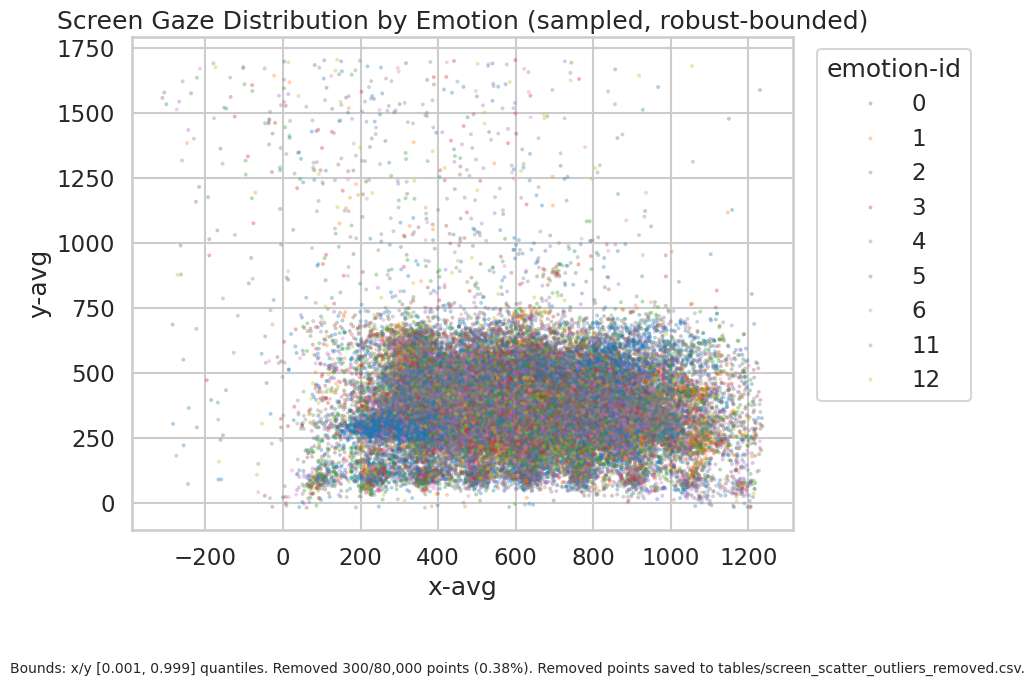

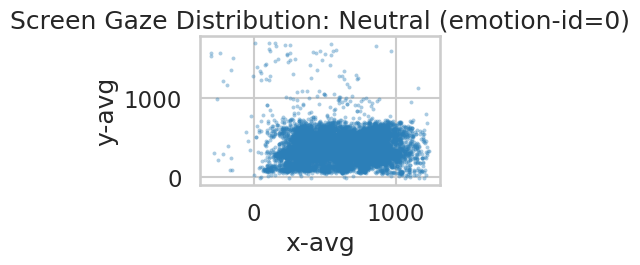

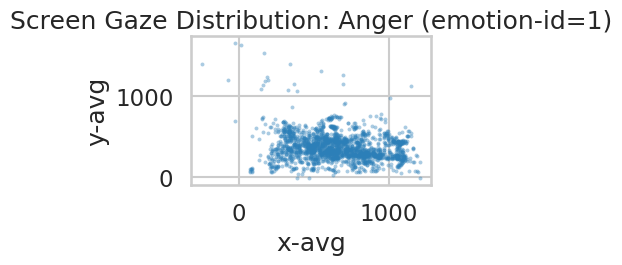

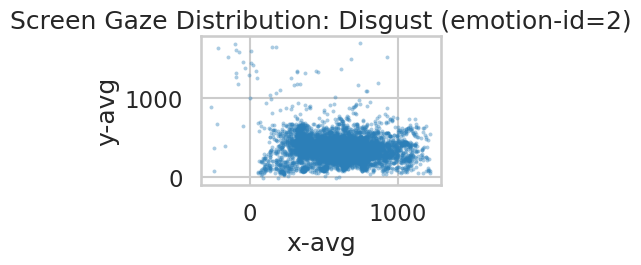

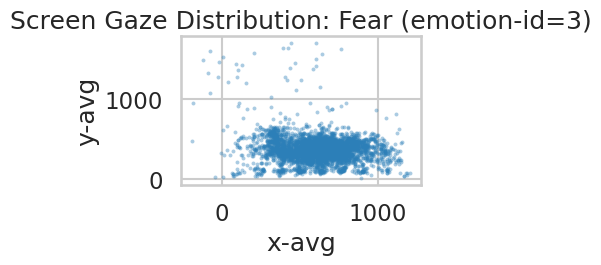

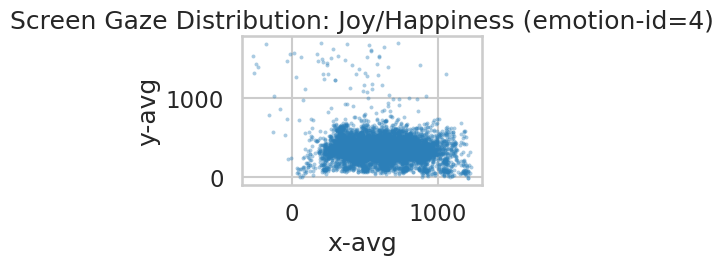

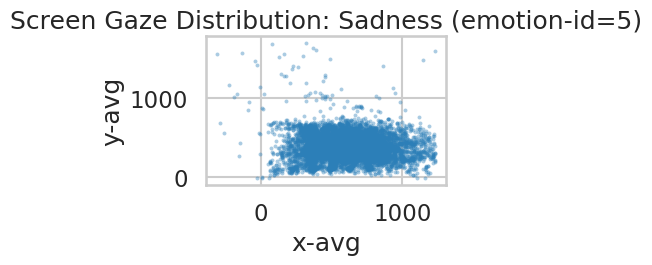

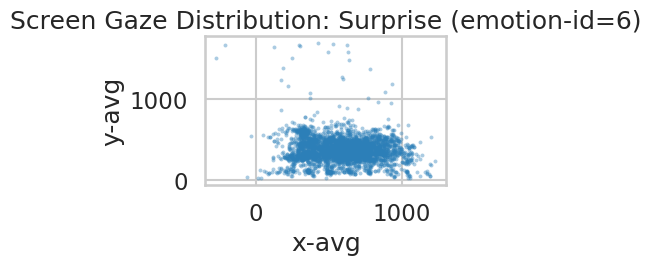

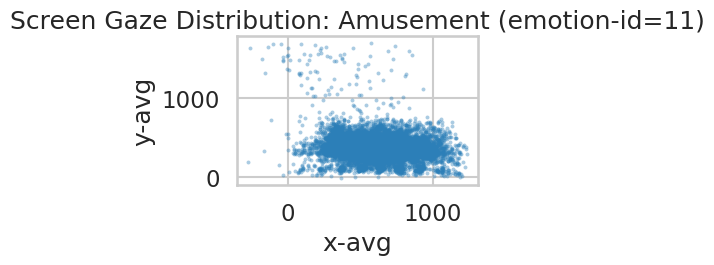

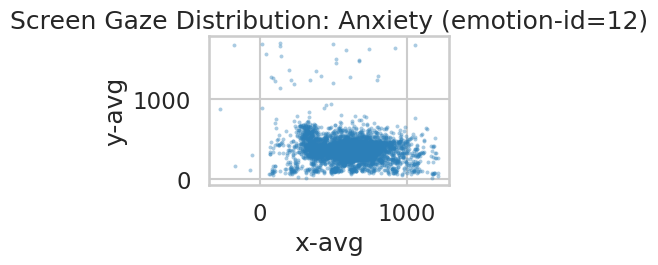

In [25]:
scatter_cols = ['x-avg', 'y-avg', 'emotion-id']
scatter_df = df_labeled.dropna(subset=scatter_cols).copy()
if len(scatter_df) > 80_000:
    scatter_df = scatter_df.sample(n=80_000, random_state=42)
scatter_df['emotion-id'] = scatter_df['emotion-id'].astype(int)

# Robustly filter extreme coordinate outliers that can collapse axis scale.
q_low = 0.001
q_high = 0.999
x_low, x_high = scatter_df['x-avg'].quantile([q_low, q_high])
y_low, y_high = scatter_df['y-avg'].quantile([q_low, q_high])

in_bounds = (
    scatter_df['x-avg'].between(x_low, x_high, inclusive='both')
    & scatter_df['y-avg'].between(y_low, y_high, inclusive='both')
)

scatter_plot_df = scatter_df[in_bounds].copy()
outlier_df = scatter_df[~in_bounds].copy()

removed_n = int((~in_bounds).sum())
total_n = int(len(scatter_df))
removed_pct = (removed_n / total_n * 100.0) if total_n else 0.0

if removed_n > 0:
    outlier_save_cols = [c for c in ['subject', 'recording', 'section', 'file-name', 'x-avg', 'y-avg', 'emotion-id'] if c in outlier_df.columns]
    outlier_df[outlier_save_cols].to_csv(TABLES_DIR / 'screen_scatter_outliers_removed.csv', index=False)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_plot_df,
    x='x-avg',
    y='y-avg',
    hue='emotion-id',
    palette='tab10',
    s=8,
    alpha=0.35,
    linewidth=0,
)
plt.title('Screen Gaze Distribution by Emotion (sampled, robust-bounded)')
plt.legend(title='emotion-id', bbox_to_anchor=(1.02, 1), loc='upper left')

note = (
    f'Bounds: x/y [{q_low:.3f}, {q_high:.3f}] quantiles. '
    f'Removed {removed_n:,}/{total_n:,} points ({removed_pct:.2f}%).'
)
if removed_n > 0:
    note += ' Removed points saved to tables/screen_scatter_outliers_removed.csv.'
if removed_pct >= 1.0:
    note += ' NOTE: axis was previously dominated by extreme values.'

plt.figtext(0.01, 0.01, note, ha='left', va='bottom', fontsize=10)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.savefig(PLOTS_DIR / 'screen_scatter_by_emotion_robust.png', dpi=180)
plt.show()

emotion_ids = scatter_plot_df['emotion-id'].unique()
emotion_ids = sorted([e for e in emotion_ids if pd.notna(e)])

for emo_id in emotion_ids:
    emo_name = emotion_id_to_name.get(int(emo_id), 'Unknown-ID')
    emo_data = scatter_plot_df[scatter_plot_df['emotion-id'] == emo_id]
    
    plt.figure(figsize=(4, 3))
    plt.scatter(emo_data['x-avg'], emo_data['y-avg'], s=8, alpha=0.4, color='#2C7FB8', linewidth=0)
    plt.title(f'Screen Gaze Distribution: {emo_name} (emotion-id={int(emo_id)})')
    plt.xlabel('x-avg')
    plt.ylabel('y-avg')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'screen_scatter_emotion_{int(emo_id)}_{emo_name.lower().replace("/", "-")}.png', dpi=180)
    plt.show()



## Pupil Size vs Arousal / Valence

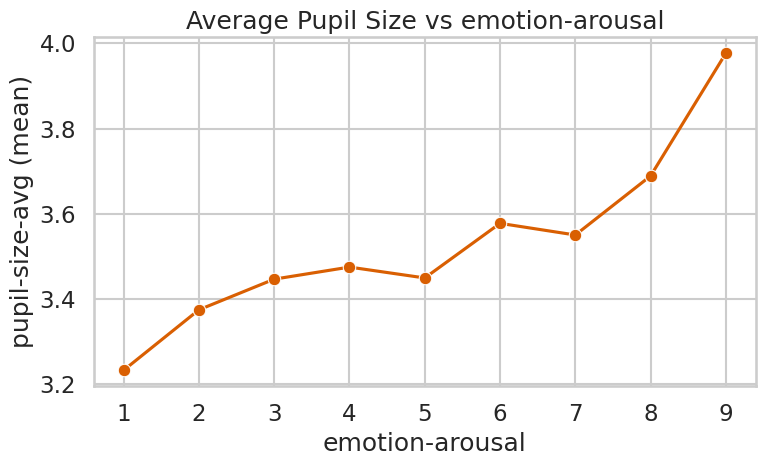

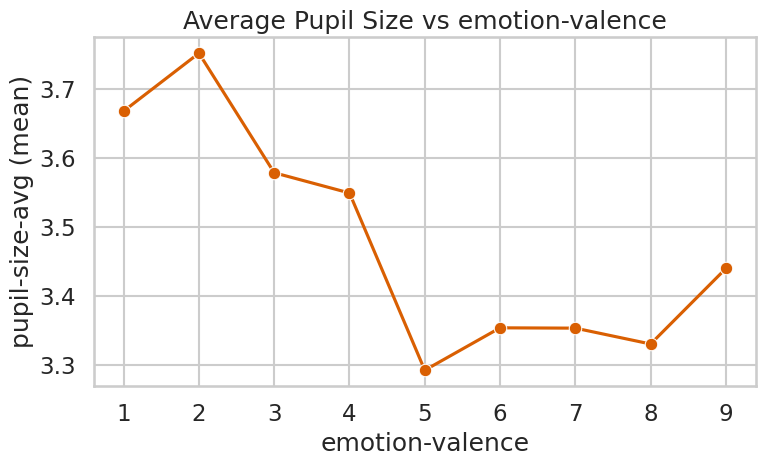

In [26]:
trend_df = df_labeled.copy()
trend_df['pupil-size-avg'] = trend_df[['pupil-size-left-avg', 'pupil-size-right-avg']].mean(axis=1)

for target_col in ['emotion-arousal', 'emotion-valence']:
    if target_col not in trend_df.columns:
        continue

    tmp = trend_df.dropna(subset=['pupil-size-avg', target_col]).copy()
    if tmp.empty:
        continue

    tmp[target_col] = tmp[target_col].astype(int)
    summary = (
        tmp.groupby(target_col)['pupil-size-avg']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .sort_values(target_col)
    )

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=summary, x=target_col, y='mean', marker='o', color='#D95F02')
    plt.title(f'Average Pupil Size vs {target_col}')
    plt.ylabel('pupil-size-avg (mean)')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'pupil_avg_vs_{target_col}.png', dpi=180)
    plt.show()

    summary.to_csv(TABLES_DIR / f'pupil_avg_vs_{target_col}.csv', index=False)

## Correlation Matrix (Signals + Emotion Dimensions)

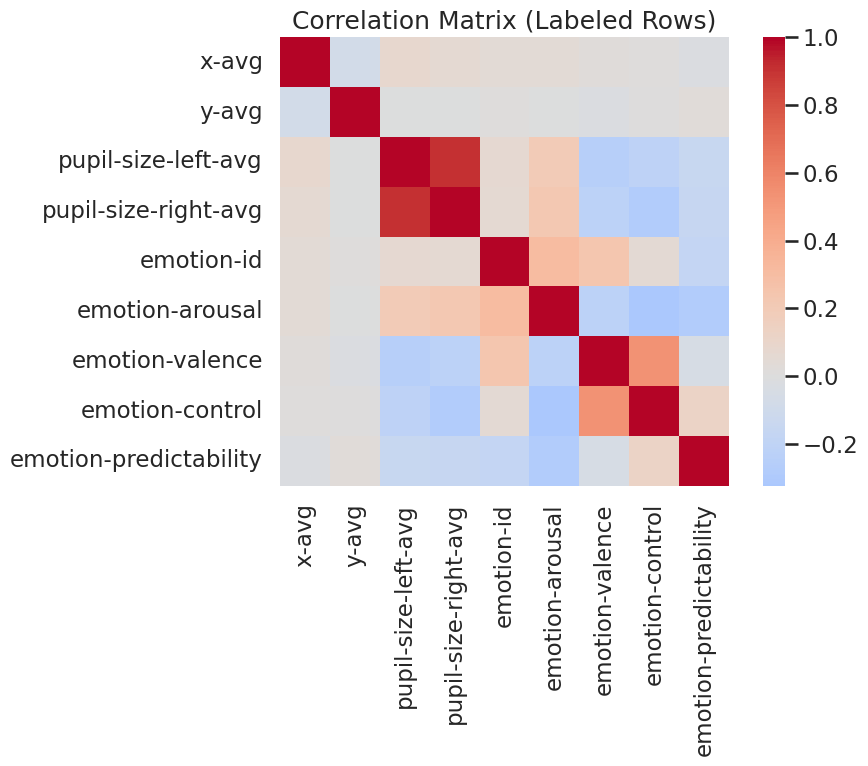

In [27]:
corr_cols = [
    'x-avg', 'y-avg',
    'pupil-size-left-avg', 'pupil-size-right-avg',
    'emotion-id', 'emotion-arousal', 'emotion-valence',
    'emotion-control', 'emotion-predictability',
]
corr_cols = [c for c in corr_cols if c in df_labeled.columns]
corr_df = df_labeled[corr_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation Matrix (Labeled Rows)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_matrix_labeled.png', dpi=180)
plt.show()

corr.to_csv(TABLES_DIR / 'correlation_matrix_labeled.csv')

## Outliers on Subject-Recording-Section Averages

In [28]:
def robust_z(series: pd.Series) -> pd.Series:
    med = series.median()
    mad = np.median(np.abs(series - med))
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return 0.6745 * (series - med) / mad

group_cols = [c for c in ['subject', 'recording', 'section'] if c in df_labeled.columns]
feature_cols = [c for c in ['x-avg','y-avg','pupil-size-left-avg','pupil-size-right-avg'] if c in df_labeled.columns]

df_group = df_labeled.groupby(group_cols, dropna=False)[feature_cols].mean().reset_index()
z_scores = pd.DataFrame({col: robust_z(df_group[col]) for col in feature_cols})
df_group['outlier-score-l2'] = np.sqrt((z_scores**2).sum(axis=1))
df_group['outlier-score-max'] = z_scores.abs().max(axis=1)

top_outliers = df_group.sort_values('outlier-score-l2', ascending=False).head(30)
display(top_outliers)
top_outliers.to_csv(TABLES_DIR / 'top_outliers_subject_recording_section.csv', index=False)

,subject,recording,section,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg,outlier-score-l2,outlier-score-max
220,P21,30.avi,28,596.121396,299.282037,5.258653,5.199243,6.365988,4.429968
280,P24,30.avi,16,634.074067,347.375222,4.904102,5.324937,5.611215,4.215915
458,P9,30.avi,12,604.091384,319.221373,4.673760,4.860176,4.678507,3.144779
225,P21,69.avi,4,611.111391,303.526683,4.620444,4.590765,4.423782,2.910574
219,P21,146.avi,36,631.060235,367.904196,4.792881,4.706140,4.365731,3.321097
340,P29,30.avi,6,579.876262,375.965784,4.693728,4.670376,4.179123,3.085042
200,P20,30.avi,32,589.189206,424.436602,4.430180,4.663026,4.104245,2.690408
297,P27,111.avi,36,620.170773,483.546199,3.003841,2.933717,4.094612,3.762485
222,P21,53.avi,26,609.975221,329.929429,4.564681,4.658412,4.074020,2.777817
218,P21,138.avi,2,667.611617,328.932479,4.522726,4.450353,3.965382,2.677934


## Left vs Right Pupil Asymmetry by Subject

,subject,mean,median,std,count
0,P28,0.589788,0.587470,0.133584,115697
1,P24,0.421477,0.403806,0.121369,118538
2,P19,0.411025,0.408464,0.080819,127948
3,P1,0.358069,0.332624,0.123736,135679
4,P18,0.345719,0.336139,0.103688,129423
5,P8,0.335283,0.326513,0.082281,116950
6,P5,0.317294,0.295402,0.111322,158650
7,P17,0.297257,0.298980,0.081769,137429
8,P13,0.283491,0.280368,0.088083,131435
9,P20,0.220002,0.209657,0.096717,124818


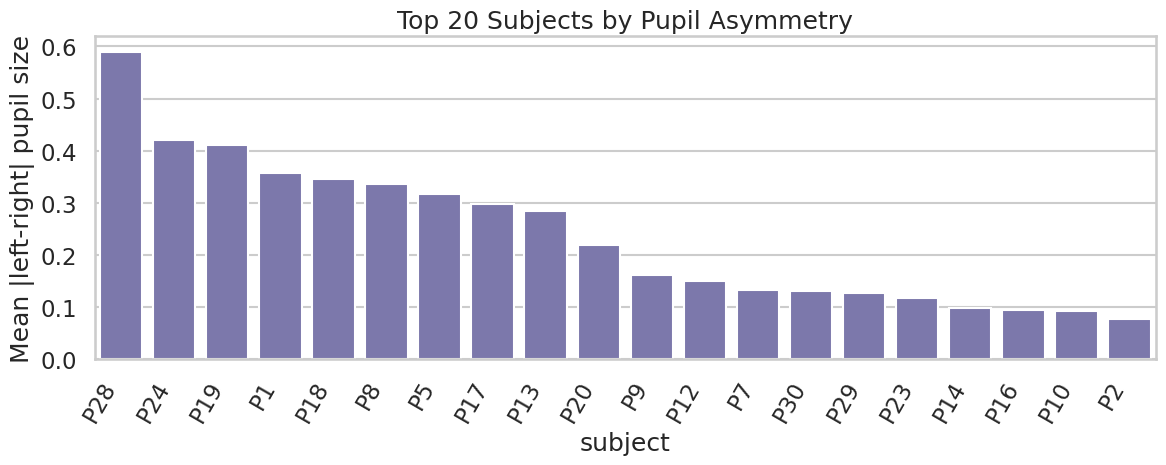

In [29]:
lr_df = df_labeled[['subject', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna().copy()
lr_df['abs_diff'] = (lr_df['pupil-size-left-avg'] - lr_df['pupil-size-right-avg']).abs()

subject_lr = (
    lr_df.groupby('subject')['abs_diff']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
display(subject_lr.head(20))

plt.figure(figsize=(12, 5))
sns.barplot(data=subject_lr.head(20), x='subject', y='mean', color='#7570B3')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Mean |left-right| pupil size')
plt.title('Top 20 Subjects by Pupil Asymmetry')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'top20_subject_pupil_asymmetry.png', dpi=180)
plt.show()

subject_lr.to_csv(TABLES_DIR / 'subject_pupil_asymmetry.csv', index=False)

## Saved Artifacts

In [30]:
print('Plots saved to:', PLOTS_DIR)
print('Tables saved to:', TABLES_DIR)

print('Example plots:')
for p in sorted(PLOTS_DIR.glob('*.png'))[:10]:
    print(' -', p.name)

print('Example tables:')
for p in sorted(TABLES_DIR.glob('*.csv'))[:10]:
    print(' -', p.name)

Plots saved to: /home/ppg/eyetracking/GFM-for-eyetracker/src/data/EDA/plots/hci-tagging-emotion
Tables saved to: /home/ppg/eyetracking/GFM-for-eyetracker/src/data/EDA/tables/hci-tagging-emotion
Example plots:
 - correlation_matrix_labeled.png
 - emotion_by_subject_heatmap.png
 - emotion_class_distribution.png
 - nan_percentage_by_column.png
 - pupil-size-left-avg_by_emotion_boxplot.png
 - pupil-size-left-avg_by_emotion_boxplot_iqr_filtered.png
 - pupil-size-right-avg_by_emotion_boxplot.png
 - pupil-size-right-avg_by_emotion_boxplot_iqr_filtered.png
 - pupil_avg_vs_emotion-arousal.png
 - pupil_avg_vs_emotion-valence.png
Example tables:
 - cohort_summary.csv
 - correlation_matrix_labeled.csv
 - emotion_by_subject_counts.csv
 - emotion_class_distribution.csv
 - emotion_derivation_status_counts.csv
 - emotion_source_counts.csv
 - nan_percentage_by_column.csv
 - pupil-size-left-avg_by_emotion_summary.csv
 - pupil-size-left-avg_by_emotion_summary_iqr_filtered.csv
 - pupil-size-left-avg_outli